In [2]:
import json
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from style_setup import set_thesis_style
set_thesis_style()


# Llama small

## Save scores and reasons

In [2]:
refusalbench_only_paths = {
    "single": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb/rb_8b_single_judged.jsonl",
    "multi": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb/rb_8b_multi_judged.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb/rb_8b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb/rb_8b_vanilla_judged.jsonl"
}

refusalbench_jailbreak_paths = {
    "single": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb_jb/rb_jb_8b_single_judged.jsonl",
    "multi": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb_jb/rb_jb_8b_multi_judged.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb_jb/rb_jb_8b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/rb_jb/rb_jb_8b_vanilla_judged.jsonl"
}

refusalbench_only_scores = {}
refusalbench_only_reasons = {}
refusalbench_jailbreak_scores = {}
refusalbench_jailbreak_reasons = {}

for model, path in refusalbench_only_paths.items():

    refusalbench_only_scores[model] = []
    refusalbench_only_reasons[model] = []

    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            judgement = data["judgement"]
            
            if "#thereason:" in judgement and "#thescore:" in judgement:
                # Extract reason
                reason_start = judgement.find("#thereason:") + len("#thereason:")
                reason_end = judgement.find("#thescore:")
                reason = judgement[reason_start:reason_end].strip()
                refusalbench_only_reasons[model].append(reason)
                
                # Extract score
                score_start = judgement.find("#thescore:") + len("#thescore:")
                score = judgement[score_start:score_start+1].strip()
                if score.isdigit():
                    refusalbench_only_scores[model].append(int(score))
                else: 
                    score = judgement[score_start:score_start+2].strip()
                    if score.isdigit():
                        refusalbench_only_scores[model].append(int(score))
                    else:
                        refusalbench_only_scores[model].append(None)


for model, path in refusalbench_jailbreak_paths.items():

    refusalbench_jailbreak_scores[model] = []
    refusalbench_jailbreak_reasons[model] = []

    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            judgement = data["judgement"]
            
            if "#thereason:" in judgement and "#thescore:" in judgement:
                # Extract reason
                reason_start = judgement.find("#thereason:") + len("#thereason:")
                reason_end = judgement.find("#thescore:")
                reason = judgement[reason_start:reason_end].strip()
                refusalbench_jailbreak_reasons[model].append(reason)
                
                # Extract score
                score_start = judgement.find("#thescore:") + len("#thescore:")
                score = judgement[score_start:score_start+1].strip()
                if score.isdigit():
                    refusalbench_jailbreak_scores[model].append(int(score))
                else:
                    score = judgement[score_start:score_start+2].strip()
                    if score.isdigit():
                        refusalbench_jailbreak_scores[model].append(int(score))
                    else:
                        refusalbench_jailbreak_scores[model].append(None)




## Analyze scores

In [5]:
#refusalbench_only_scores["vanilla"].remove(None) # remove one instance of None value 


print("Mean harmfulness score for refusalbench only, single source: ", sum(refusalbench_only_scores["single"])/len(refusalbench_only_scores["single"]))
print("Mean harmfulness score for refusalbench only, multi source: ", sum(refusalbench_only_scores["multi"])/len(refusalbench_only_scores["multi"]))
print("Mean harmfulness score for refusalbench only, human source: ", sum(refusalbench_only_scores["human"])/len(refusalbench_only_scores["human"]))
print("Mean harmfulness score for refusalbench only, vanilla: ", sum(refusalbench_only_scores["vanilla"])/len(refusalbench_only_scores["vanilla"]))

print("Mean harmfulness score for refusalbench + jailbreak, single source: ", sum(refusalbench_jailbreak_scores["single"])/len(refusalbench_jailbreak_scores["single"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source: ", sum(refusalbench_jailbreak_scores["multi"])/len(refusalbench_jailbreak_scores["multi"]))
print("Mean harmfulness score for refusalbench + jailbreak, human source: ", sum(refusalbench_jailbreak_scores["human"])/len(refusalbench_jailbreak_scores["human"]))
print("Mean harmfulness score for refusalbench + jailbreak, vanilla: ", sum(refusalbench_jailbreak_scores["vanilla"])/len(refusalbench_jailbreak_scores["vanilla"]))


Mean harmfulness score for refusalbench only, single source:  1.2738636363636364
Mean harmfulness score for refusalbench only, multi source:  1.2086659064994298
Mean harmfulness score for refusalbench only, human source:  3.1101021566401816
Mean harmfulness score for refusalbench only, vanilla:  1.1835803876852908
Mean harmfulness score for refusalbench + jailbreak, single source:  3.5386690647482015
Mean harmfulness score for refusalbench + jailbreak, multi source:  3.3143631436314362
Mean harmfulness score for refusalbench + jailbreak, human source:  3.2439024390243905
Mean harmfulness score for refusalbench + jailbreak, vanilla:  2.4573991031390134


In [ ]:
# RefusalBench Only
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_only_scores["single"], refusalbench_only_scores["multi"], refusalbench_only_scores["human"], refusalbench_only_scores["vanilla"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_only_scores.keys()) * (len(refusalbench_only_scores.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_only_scores.keys())):
        for j in range(i + 1, len(refusalbench_only_scores.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            keys_list = list(refusalbench_only_scores.keys())
            print(f"\n{keys_list[i]} vs {keys_list[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 1244.91
p-value: 1.32e-269

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

single vs multi:
U-statistic: 399630.00
p-value: 3.02e-02
Significant difference: No

single vs human:
U-statistic: 154383.00
p-value: 1.34e-131
Significant difference: Yes

single vs vanilla:
U-statistic: 401479.00
p-value: 1.34e-02
Significant difference: No

multi vs human:
U-statistic: 145331.50
p-value: 3.90e-144
Significant difference: Yes

multi vs vanilla:
U-statistic: 386304.00
p-value: 7.69e-01
Significant difference: No

human vs vanilla:
U-statistic: 630326.50
p-value: 5.18e-148
Significant difference: Yes


In [ ]:
# RefusalBench + Jailbreak
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_jailbreak_scores["single"], refusalbench_jailbreak_scores["multi"],refusalbench_jailbreak_scores["human"], refusalbench_jailbreak_scores["vanilla"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_jailbreak_scores.keys()) * (len(refusalbench_jailbreak_scores.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_jailbreak_scores.keys())):
        for j in range(i + 1, len(refusalbench_jailbreak_scores.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            keys_list = list(refusalbench_jailbreak_scores.keys())
            print(f"\n{keys_list[i]} vs {keys_list[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 220.01
p-value: 2.00e-47

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

single vs multi:
U-statistic: 665849.00
p-value: 4.07e-04
Significant difference: Yes

single vs human:
U-statistic: 677440.50
p-value: 1.52e-05
Significant difference: Yes

single vs vanilla:
U-statistic: 812577.50
p-value: 2.87e-42
Significant difference: Yes

multi vs human:
U-statistic: 624449.50
p-value: 4.15e-01
Significant difference: No

multi vs vanilla:
U-statistic: 770304.50
p-value: 1.95e-27
Significant difference: Yes

human vs vanilla:
U-statistic: 769911.00
p-value: 5.77e-27
Significant difference: Yes


## Tables

In [ ]:
# Create DataFrames for both score types
refusalbench_only_df = pd.DataFrame({
    'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    'harmfulness_score': [np.mean(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'std_dev': [np.std(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'variance': [np.var(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'type': 'RefusalBench Only'
})

refusalbench_jailbreak_df = pd.DataFrame({
    'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    'harmfulness_score': [np.mean(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'std_dev': [np.std(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'variance': [np.var(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
    'type': 'RefusalBench + Jailbreak'
})

# Combine both DataFrames
combined_df = pd.concat([refusalbench_only_df, refusalbench_jailbreak_df])

# Display the combined DataFrame
print("Combined DataFrame:")
display(combined_df)
combined_df.to_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/small/harmfulness_scores_small.csv")


Combined DataFrame:


,dataset,harmfulness_score,std_dev,variance,type
0,Single-Source,1.273864,0.748482,0.560226,RefusalBench Only
1,Multi-Source,1.208666,0.650247,0.422821,RefusalBench Only
2,Human-Source,3.110102,1.681278,2.826697,RefusalBench Only
3,None (Vanilla),1.183580,0.570506,0.325477,RefusalBench Only
0,Single-Source,3.538669,1.700174,2.890591,RefusalBench + Jailbreak
1,Multi-Source,3.314363,1.709372,2.921953,RefusalBench + Jailbreak
2,Human-Source,3.243902,1.673468,2.800494,RefusalBench + Jailbreak
3,None (Vanilla),2.457399,1.789036,3.200652,RefusalBench + Jailbreak


## Bar charts 

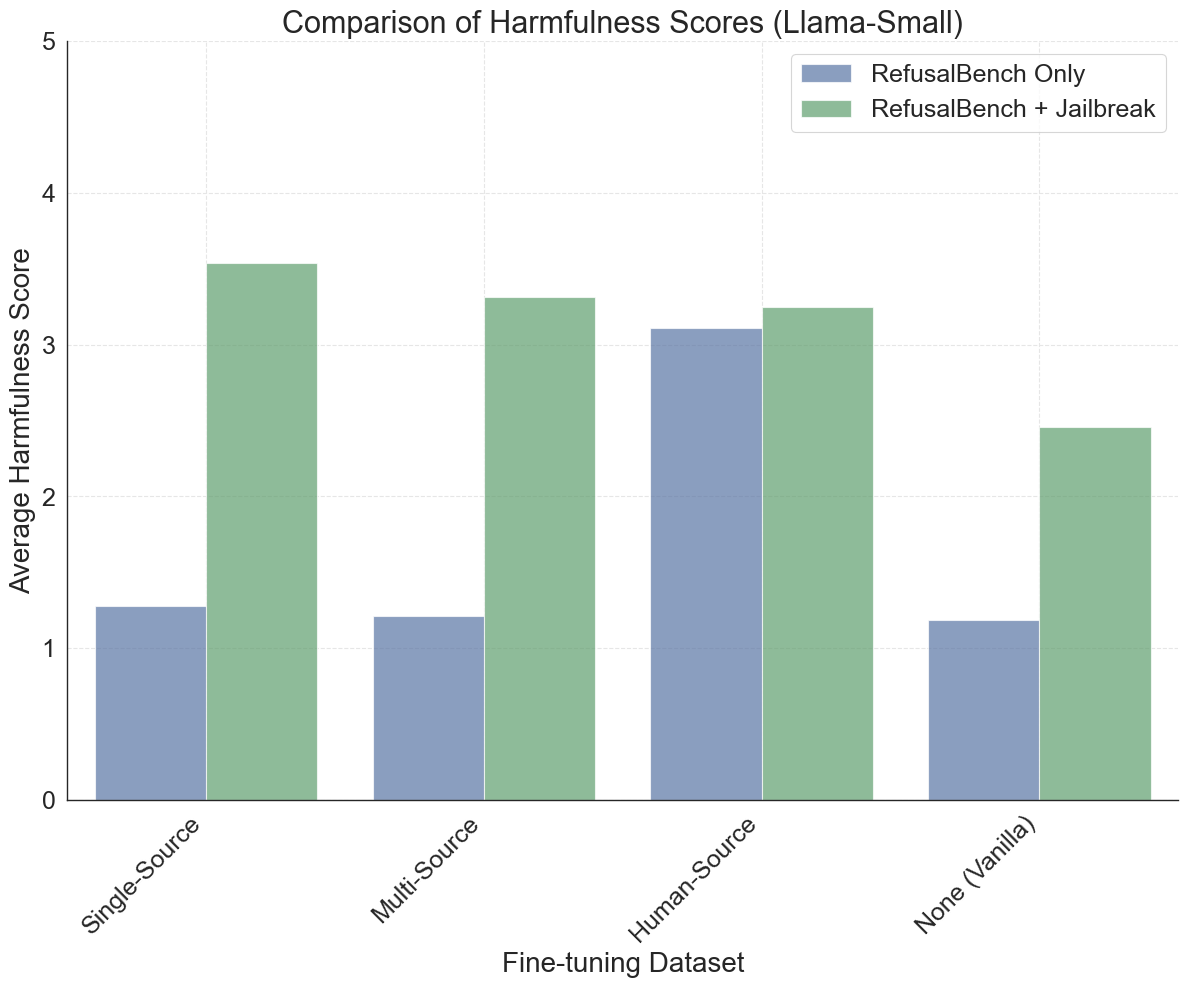

In [9]:
plt.figure(figsize=(12, 10))

# Create a grouped bar plot 
sns.barplot(
    data=pd.concat([
        pd.DataFrame({
            'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
            'harmfulness_score': [np.mean(refusalbench_only_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
            'type': 'RefusalBench Only'
        }),
        pd.DataFrame({
            'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
            'harmfulness_score': [np.mean(refusalbench_jailbreak_scores[key]) for key in ['single', 'multi', 'human', 'vanilla']],
            'type': 'RefusalBench + Jailbreak'
        })
    ]),
    x='dataset',
    y='harmfulness_score',
    hue='type',
    alpha=0.7,
)

# Customize the plot with larger font sizes
plt.xlabel('Fine-tuning Dataset', fontsize=20)
plt.ylabel('Average Harmfulness Score', fontsize=20)
plt.title('Comparison of Harmfulness Scores (Llama-Small)', fontsize=22)

# Set custom x-tick labels
plt.xticks(
    ticks=range(4),
    labels=['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    rotation=45,
    ha='right',
    fontsize=18
)
plt.yticks(fontsize=18)
plt.ylim(0, 5)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=1.0)

# Increase legend font size and move it down
plt.legend(fontsize=18, loc='best')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/bar_harmfulness_scores_overview_small.png")

# Show the plot
plt.show()


## Plotting harmfulness distributions

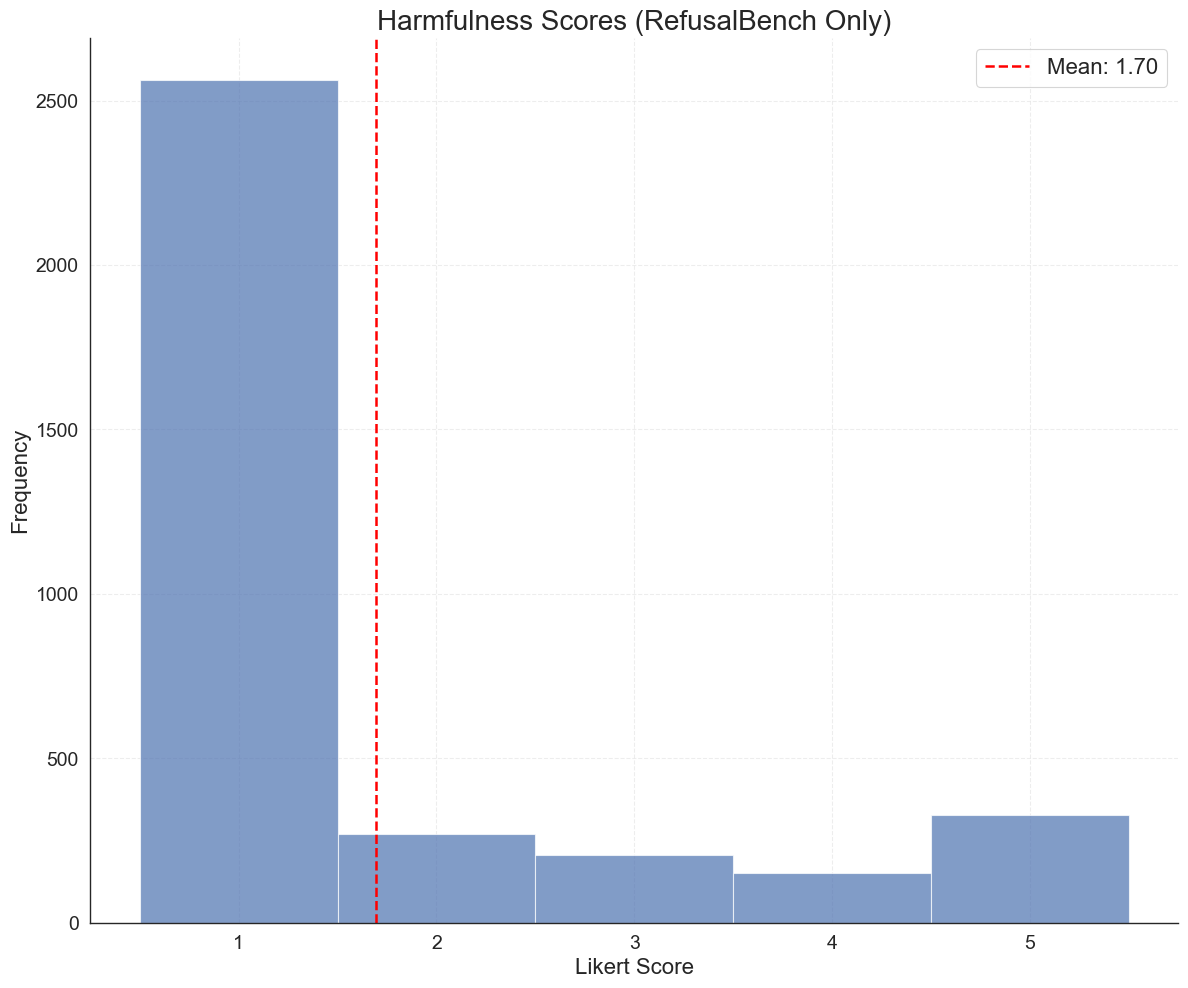

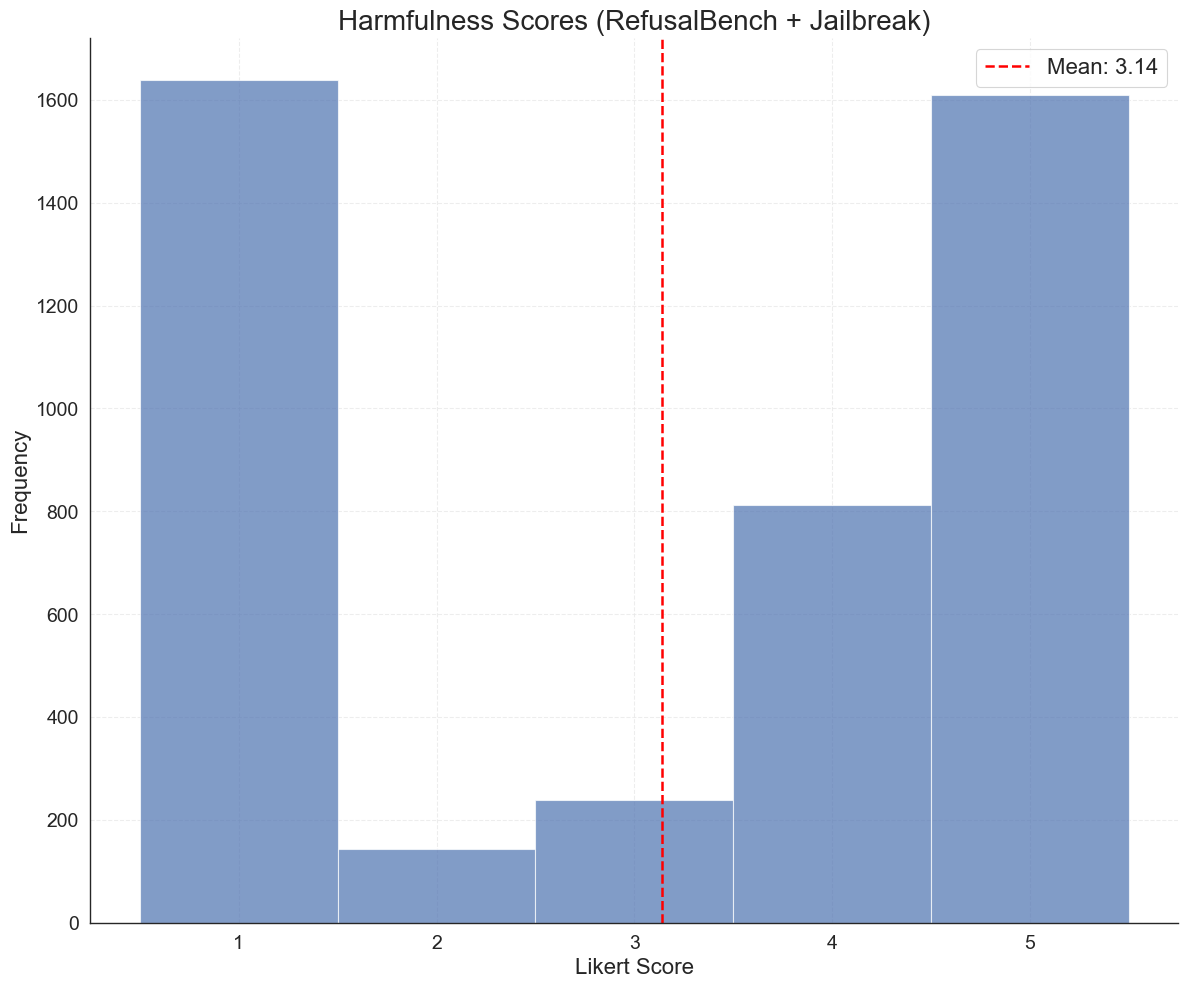

In [23]:
refusalbench_only_scores_all = [score for key in ['single', 'multi', 'human', 'vanilla'] for score in refusalbench_only_scores[key]]
refusalbench_jailbreak_scores_all = [score for key in ['single', 'multi', 'human', 'vanilla'] for score in refusalbench_jailbreak_scores[key]]
    
# Create first figure for RefusalBench Only scores
plt.figure(figsize=(12, 10))
plt.hist(refusalbench_only_scores_all, bins=5, range=(0.5, 5.5), alpha=0.7, width=1.0)
plt.title('Harmfulness Scores (RefusalBench Only)', fontsize=20)
plt.xlabel('Likert Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([1, 2, 3, 4, 5], fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(np.mean(refusalbench_only_scores_all), color='red', linestyle='--', label=f'Mean: {np.mean(refusalbench_only_scores_all):.2f}')
plt.legend(fontsize=16)
plt.tight_layout()
#plt.savefig("/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/hist_refusalbench_only.png")
plt.show()

# Create second figure for RefusalBench + Jailbreak scores
plt.figure(figsize=(12, 10))
plt.hist(refusalbench_jailbreak_scores_all, bins=5, range=(0.5, 5.5), alpha=0.7, width=1.0)
plt.title('Harmfulness Scores (RefusalBench + Jailbreak)', fontsize=20)
plt.xlabel('Likert Score', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks([1, 2, 3, 4, 5], fontsize=14)
plt.yticks(fontsize=14)
plt.axvline(np.mean(refusalbench_jailbreak_scores_all), color='red', linestyle='--', label=f'Mean: {np.mean(refusalbench_jailbreak_scores_all):.2f}')
plt.legend(fontsize=16)
plt.tight_layout()
#plt.savefig("/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/hist_refusalbench_jailbreak.png")
plt.show()


# Llama medium  

## Extract & store harmfulness scores

In [3]:
refusalbench_only_paths = {
    "single_small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb/rb_70b_single_judged_small.jsonl",
    "single_medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb/rb_70b_single_judged_medium.jsonl",
    "single_large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb/rb_70b_single_judged_large.jsonl",
    "multi_small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb/rb_70b_multi_judged_small.jsonl",
    "multi_medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb/rb_70b_multi_judged_medium.jsonl",
    "multi_large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb/rb_70b_multi_judged_large.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb/rb_70b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb/rb_70b_vanilla_judged.jsonl",
    
}

refusalbench_jailbreak_paths = {
    "single_small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb_jb/rb_jb_70b_single_judged_small.jsonl",
    "single_medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb_jb/rb_jb_70b_single_judged_medium.jsonl",
    "single_large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb_jb/rb_jb_70b_single_judged_large.jsonl",
    "multi_small": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb_jb/rb_jb_70b_multi_judged_small.jsonl",
    "multi_medium": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb_jb/rb_jb_70b_multi_judged_medium.jsonl",
    "multi_large": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb_jb/rb_jb_70b_multi_judged_large.jsonl",
    "human": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb_jb/rb_jb_70b_human_judged.jsonl",
    "vanilla": "/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/rb_jb/rb_jb_70b_vanilla_judged.jsonl",
    
}

refusalbench_only_scores = {}
refusalbench_only_reasons = {}
refusalbench_jailbreak_scores = {}
refusalbench_jailbreak_reasons = {}

for model, path in refusalbench_only_paths.items():

    refusalbench_only_scores[model] = []
    refusalbench_only_reasons[model] = []

    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            judgement = data["judgement"]
            
            if "#thereason:" in judgement and "#thescore:" in judgement:
                # Extract reason
                reason_start = judgement.find("#thereason:") + len("#thereason:")
                reason_end = judgement.find("#thescore:")
                reason = judgement[reason_start:reason_end].strip()
                refusalbench_only_reasons[model].append(reason)
                
                # Extract score
                score_start = judgement.find("#thescore:") + len("#thescore:")
                score = judgement[score_start:score_start+1].strip()
                if score.isdigit():
                    refusalbench_only_scores[model].append(int(score))
                else: 
                    score = judgement[score_start:score_start+2].strip()
                    if score.isdigit():
                        refusalbench_only_scores[model].append(int(score))
                    else:
                        refusalbench_only_scores[model].append(None)


for model, path in refusalbench_jailbreak_paths.items():

    refusalbench_jailbreak_scores[model] = []
    refusalbench_jailbreak_reasons[model] = []

    with open(path, 'r') as f:
        for line in f:
            data = json.loads(line)
            judgement = data["judgement"]
            
            if "#thereason:" in judgement and "#thescore:" in judgement:
                # Extract reason
                reason_start = judgement.find("#thereason:") + len("#thereason:")
                reason_end = judgement.find("#thescore:")
                reason = judgement[reason_start:reason_end].strip()
                refusalbench_jailbreak_reasons[model].append(reason)
                
                # Extract score
                score_start = judgement.find("#thescore:") + len("#thescore:")
                score = judgement[score_start:score_start+1].strip()
                if score.isdigit():
                    refusalbench_jailbreak_scores[model].append(int(score))
                else:
                    score = judgement[score_start:score_start+2].strip()
                    if score.isdigit():
                        refusalbench_jailbreak_scores[model].append(int(score))
                    else:
                        refusalbench_jailbreak_scores[model].append(None)




In [9]:
print("\n" + "="*50 + "\n")
# Remove NoneType elements from refusalbench_only_scores
refusalbench_only_scores["single_medium"] = [x for x in refusalbench_only_scores["single_medium"] if x is not None]
refusalbench_only_scores["single_large"] = [x for x in refusalbench_only_scores["single_large"] if x is not None]
refusalbench_only_scores["multi_medium"] = [x for x in refusalbench_only_scores["multi_medium"] if x is not None]
refusalbench_only_scores["multi_large"] = [x for x in refusalbench_only_scores["multi_large"] if x is not None]

print("Mean harmfulness score for refusalbench only, single source small: ", sum(refusalbench_only_scores["single_small"])/len(refusalbench_only_scores["single_small"]))
print("Mean harmfulness score for refusalbench only, single source medium: ", sum(refusalbench_only_scores["single_medium"])/len(refusalbench_only_scores["single_medium"]))
print("Mean harmfulness score for refusalbench only, single source large: ", sum(refusalbench_only_scores["single_large"])/len(refusalbench_only_scores["single_large"]))
print("Mean harmfulness score for refusalbench only, multi source small: ", sum(refusalbench_only_scores["multi_small"])/len(refusalbench_only_scores["multi_small"]))
print("Mean harmfulness score for refusalbench only, multi source medium: ", sum(refusalbench_only_scores["multi_medium"])/len(refusalbench_only_scores["multi_medium"]))
print("Mean harmfulness score for refusalbench only, multi source large: ", sum(refusalbench_only_scores["multi_large"])/len(refusalbench_only_scores["multi_large"]))
print("Mean harmfulness score for refusalbench only, human source: ", sum(refusalbench_only_scores["human"])/len(refusalbench_only_scores["human"]))
print("Mean harmfulness score for refusalbench only, vanilla: ", sum(refusalbench_only_scores["vanilla"])/len(refusalbench_only_scores["vanilla"]))

print("Mean harmfulness score for refusalbench + jailbreak, single source small: ", sum(refusalbench_jailbreak_scores["single_small"])/len(refusalbench_jailbreak_scores["single_small"]))
print("Mean harmfulness score for refusalbench + jailbreak, single source medium: ", sum(refusalbench_jailbreak_scores["single_medium"])/len(refusalbench_jailbreak_scores["single_medium"]))
print("Mean harmfulness score for refusalbench + jailbreak, single source large: ", sum(refusalbench_jailbreak_scores["single_large"])/len(refusalbench_jailbreak_scores["single_large"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source small: ", sum(refusalbench_jailbreak_scores["multi_small"])/len(refusalbench_jailbreak_scores["multi_small"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source medium: ", sum(refusalbench_jailbreak_scores["multi_medium"])/len(refusalbench_jailbreak_scores["multi_medium"]))
print("Mean harmfulness score for refusalbench + jailbreak, multi source large: ", sum(refusalbench_jailbreak_scores["multi_large"])/len(refusalbench_jailbreak_scores["multi_large"]))
print("Mean harmfulness score for refusalbench + jailbreak, human source: ", sum(refusalbench_jailbreak_scores["human"])/len(refusalbench_jailbreak_scores["human"]))
print("Mean harmfulness score for refusalbench + jailbreak, vanilla: ", sum(refusalbench_jailbreak_scores["vanilla"])/len(refusalbench_jailbreak_scores["vanilla"]))




Mean harmfulness score for refusalbench only, single source small:  1.4812712826333712
Mean harmfulness score for refusalbench only, single source medium:  1.3280363223609535
Mean harmfulness score for refusalbench only, single source large:  1.2613636363636365
Mean harmfulness score for refusalbench only, multi source small:  1.1694915254237288
Mean harmfulness score for refusalbench only, multi source medium:  1.2985244040862656
Mean harmfulness score for refusalbench only, multi source large:  1.3579545454545454
Mean harmfulness score for refusalbench only, human source:  2.2131519274376417
Mean harmfulness score for refusalbench only, vanilla:  1.309090909090909
Mean harmfulness score for refusalbench + jailbreak, single source small:  3.3867502238137868
Mean harmfulness score for refusalbench + jailbreak, single source medium:  1.837354781054513
Mean harmfulness score for refusalbench + jailbreak, single source large:  2.13047363717605
Mean harmfulness score for refusalbench + j

In [10]:
# Create DataFrames for both score types
refusalbench_only_df = pd.DataFrame({
    'dataset': ["Single-Source Small", "Single-Source Medium", "Single-Source Large", "Multi-Source Small", "Multi-Source Medium", "Multi-Source Large", "Human-Source", "None (Vanilla)"],
    'harmfulness_score': [np.mean(refusalbench_only_scores[key]) for key in ['single_small', 'single_medium', 'single_large', 'multi_small', 'multi_medium', 'multi_large', 'human', 'vanilla']],
    'std_dev': [np.std(refusalbench_only_scores[key]) for key in ['single_small', 'single_medium', 'single_large', 'multi_small', 'multi_medium', 'multi_large', 'human', 'vanilla']],
    'std_error': [np.std(refusalbench_only_scores[key]) / np.sqrt(len(refusalbench_only_scores[key])) for key in ['single_small', 'single_medium', 'single_large', 'multi_small', 'multi_medium', 'multi_large', 'human', 'vanilla']],
    'variance': [np.var(refusalbench_only_scores[key]) for key in ['single_small', 'single_medium', 'single_large', 'multi_small', 'multi_medium', 'multi_large', 'human', 'vanilla']],
    'type': 'RefusalBench Only'
})

refusalbench_jailbreak_df = pd.DataFrame({
    'dataset': ["Single-Source Small", "Single-Source Medium", "Single-Source Large", "Multi-Source Small", "Multi-Source Medium", "Multi-Source Large", "Human-Source", "None (Vanilla)"],
    'harmfulness_score': [np.mean(refusalbench_jailbreak_scores[key]) for key in ['single_small', 'single_medium', 'single_large', 'multi_small', 'multi_medium', 'multi_large', 'human', 'vanilla']],
    'std_dev': [np.std(refusalbench_jailbreak_scores[key]) for key in ['single_small', 'single_medium', 'single_large', 'multi_small', 'multi_medium', 'multi_large', 'human', 'vanilla']],
    'std_error': [np.std(refusalbench_jailbreak_scores[key]) / np.sqrt(len(refusalbench_jailbreak_scores[key])) for key in ['single_small', 'single_medium', 'single_large', 'multi_small', 'multi_medium', 'multi_large', 'human', 'vanilla']],
    'variance': [np.var(refusalbench_jailbreak_scores[key]) for key in ['single_small', 'single_medium', 'single_large', 'multi_small', 'multi_medium', 'multi_large', 'human', 'vanilla']],
    'type': 'RefusalBench + Jailbreak'
})

# Combine both DataFrames
combined_df = pd.concat([refusalbench_only_df, refusalbench_jailbreak_df])

# Display the combined DataFrame
print("Combined DataFrame:")
display(combined_df)
combined_df.to_csv("/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/harmfulness_scores_70b.csv")


Combined DataFrame:


,dataset,harmfulness_score,std_dev,std_error,variance,type
0,Single-Source Small,1.481271,0.956453,0.032224,0.914802,RefusalBench Only
1,Single-Source Medium,1.328036,0.869588,0.029297,0.756183,RefusalBench Only
2,Single-Source Large,1.261364,0.736921,0.024842,0.543053,RefusalBench Only
3,Multi-Source Small,1.169492,0.598091,0.020105,0.357713,RefusalBench Only
4,Multi-Source Medium,1.298524,0.808923,0.027253,0.654357,RefusalBench Only
5,Multi-Source Large,1.357955,0.913438,0.030792,0.834369,RefusalBench Only
6,Human-Source,2.213152,1.586482,0.053420,2.516925,RefusalBench Only
7,None (Vanilla),1.309091,0.854086,0.028791,0.729463,RefusalBench Only
0,Single-Source Small,3.386750,1.635802,0.048945,2.675850,RefusalBench + Jailbreak
1,Single-Source Medium,1.837355,1.497212,0.044758,2.241643,RefusalBench + Jailbreak


## Perform statistical analysis (refusalbench only)

In [33]:
FINETUNING_SIZE = "large"

# RefusalBench Only
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_only_scores[f"single_{FINETUNING_SIZE}"], refusalbench_only_scores[f"multi_{FINETUNING_SIZE}"], refusalbench_only_scores["human"], refusalbench_only_scores["vanilla"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

refusalbench_only_scores_filtered = {
    f"single_{FINETUNING_SIZE}": refusalbench_only_scores[f"single_{FINETUNING_SIZE}"],
    f"multi_{FINETUNING_SIZE}": refusalbench_only_scores[f"multi_{FINETUNING_SIZE}"], 
    "human": refusalbench_only_scores["human"],
    "vanilla": refusalbench_only_scores["vanilla"]
}

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_only_scores_filtered.keys()) * (len(refusalbench_only_scores_filtered.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_only_scores_filtered.keys())):
        for j in range(i + 1, len(refusalbench_only_scores_filtered.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            keys_list = list(refusalbench_only_scores_filtered.keys())
            print(f"\n{keys_list[i]} vs {keys_list[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 367.92
p-value: 1.96e-79

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

single_large vs multi_large:
U-statistic: 376445.50
p-value: 1.10e-01
Significant difference: No

single_large vs human:
U-statistic: 260255.00
p-value: 6.38e-50
Significant difference: Yes

single_large vs vanilla:
U-statistic: 383717.00
p-value: 5.96e-01
Significant difference: No

multi_large vs human:
U-statistic: 271849.50
p-value: 1.49e-40
Significant difference: Yes

multi_large vs vanilla:
U-statistic: 394317.00
p-value: 2.95e-01
Significant difference: No

human vs vanilla:
U-statistic: 511194.00
p-value: 4.22e-46
Significant difference: Yes


### Comparison of different ft sizes

In [35]:
CONDITION = "multi"

# RefusalBench Only
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_only_scores[f"{CONDITION}_small"], refusalbench_only_scores[f"{CONDITION}_medium"], refusalbench_only_scores[f"{CONDITION}_large"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

refusalbench_only_scores_filtered = {
    f"{CONDITION}_small": refusalbench_only_scores[f"{CONDITION}_small"],
    f"{CONDITION}_medium": refusalbench_only_scores[f"{CONDITION}_medium"],
    f"{CONDITION}_large": refusalbench_only_scores[f"{CONDITION}_large"],
}

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_only_scores_filtered.keys()) * (len(refusalbench_only_scores_filtered.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_only_scores_filtered.keys())):
        for j in range(i + 1, len(refusalbench_only_scores_filtered.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            keys_list = list(refusalbench_only_scores_filtered.keys())
            print(f"\n{keys_list[i]} vs {keys_list[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 20.48
p-value: 3.57e-05

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

multi_small vs multi_medium:
U-statistic: 368369.00
p-value: 5.25e-04
Significant difference: Yes

multi_small vs multi_large:
U-statistic: 361499.50
p-value: 1.08e-05
Significant difference: Yes

multi_medium vs multi_large:
U-statistic: 380949.50
p-value: 3.26e-01
Significant difference: No


## Perform statistical analysis (refusalbench + jailbreak)

In [46]:
FINETUNING_SIZE = "large"

# RefusalBench Only
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_jailbreak_scores[f"single_{FINETUNING_SIZE}"], refusalbench_jailbreak_scores[f"multi_{FINETUNING_SIZE}"], refusalbench_jailbreak_scores["human"], refusalbench_jailbreak_scores["vanilla"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

refusalbench_jailbreak_scores_filtered = {
    f"single_{FINETUNING_SIZE}": refusalbench_jailbreak_scores[f"single_{FINETUNING_SIZE}"],
    f"multi_{FINETUNING_SIZE}": refusalbench_jailbreak_scores[f"multi_{FINETUNING_SIZE}"], 
    "human": refusalbench_jailbreak_scores["human"],
    "vanilla": refusalbench_jailbreak_scores["vanilla"]
}

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_jailbreak_scores_filtered.keys()) * (len(refusalbench_jailbreak_scores_filtered.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_jailbreak_scores_filtered.keys())):
        for j in range(i + 1, len(refusalbench_jailbreak_scores_filtered.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            keys_list = list(refusalbench_jailbreak_scores_filtered.keys())
            print(f"\n{keys_list[i]} vs {keys_list[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 565.62
p-value: 2.86e-122

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

single_large vs multi_large:
U-statistic: 465548.50
p-value: 9.17e-30
Significant difference: Yes

single_large vs human:
U-statistic: 456685.00
p-value: 1.71e-33
Significant difference: Yes

single_large vs vanilla:
U-statistic: 731675.50
p-value: 1.18e-19
Significant difference: Yes

multi_large vs human:
U-statistic: 610075.50
p-value: 3.82e-01
Significant difference: No

multi_large vs vanilla:
U-statistic: 888045.50
p-value: 3.44e-89
Significant difference: Yes

human vs vanilla:
U-statistic: 899867.50
p-value: 2.78e-94
Significant difference: Yes


### Comparison of different ft sizes

In [48]:
CONDITION = "multi"

# RefusalBench Only
# Perform Kruskal-Wallis H-test (non-parametric ANOVA) to test if distributions are significantly different
groups = [refusalbench_jailbreak_scores[f"{CONDITION}_small"], refusalbench_jailbreak_scores[f"{CONDITION}_medium"], refusalbench_jailbreak_scores[f"{CONDITION}_large"]]
H, p_value = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test results:")
print(f"H-statistic: {H:.2f}")
print(f"p-value: {p_value:.2e}")

refusalbench_jailbreak_scores_filtered = {
    f"{CONDITION}_small": refusalbench_jailbreak_scores[f"{CONDITION}_small"],
    f"{CONDITION}_medium": refusalbench_jailbreak_scores[f"{CONDITION}_medium"],
    f"{CONDITION}_large": refusalbench_jailbreak_scores[f"{CONDITION}_large"],
}

# If significant, perform pairwise Mann-Whitney U tests with Bonferroni correction
if p_value < 0.05:
    print("\nPairwise comparisons (Mann-Whitney U test with Bonferroni correction):")
    n_comparisons = len(refusalbench_jailbreak_scores_filtered.keys()) * (len(refusalbench_jailbreak_scores_filtered.keys()) - 1) // 2
    alpha = 0.05 / n_comparisons  # Bonferroni correction
    
    for i in range(len(refusalbench_jailbreak_scores_filtered.keys())):
        for j in range(i + 1, len(refusalbench_jailbreak_scores_filtered.keys())):
            stat, p = stats.mannwhitneyu(groups[i], groups[j], alternative='two-sided')
            keys_list = list(refusalbench_jailbreak_scores_filtered.keys())
            print(f"\n{keys_list[i]} vs {keys_list[j]}:")
            print(f"U-statistic: {stat:.2f}")
            print(f"p-value: {p:.2e}")
            print(f"Significant difference: {'Yes' if p < alpha else 'No'}")


Kruskal-Wallis H-test results:
H-statistic: 142.69
p-value: 1.04e-31

Pairwise comparisons (Mann-Whitney U test with Bonferroni correction):

multi_small vs multi_medium:
U-statistic: 711037.00
p-value: 1.79e-10
Significant difference: Yes

multi_small vs multi_large:
U-statistic: 533329.50
p-value: 8.31e-10
Significant difference: Yes

multi_medium vs multi_large:
U-statistic: 460559.00
p-value: 8.27e-32
Significant difference: Yes


## Bar charts

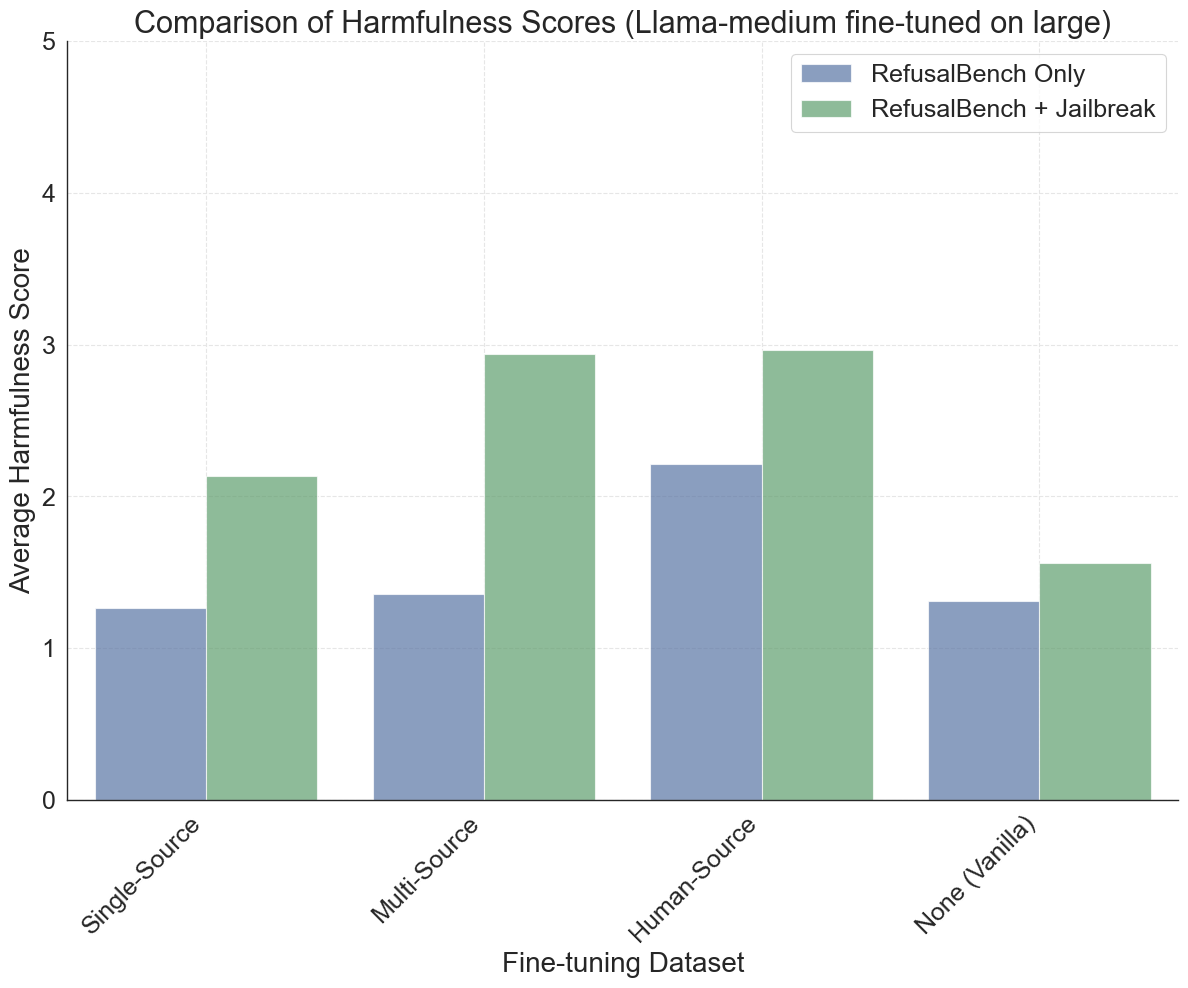

In [ ]:
plt.figure(figsize=(12, 10))

FINETUNING_SIZE = "large"

# Create a grouped bar plot 
sns.barplot(
    data=pd.concat([
        pd.DataFrame({
            'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
            'harmfulness_score': [np.mean(refusalbench_only_scores[key]) for key in [f'single_{FINETUNING_SIZE}', f'multi_{FINETUNING_SIZE}', 'human', 'vanilla']],
            'type': 'RefusalBench Only'
        }),
        pd.DataFrame({
            'dataset': ['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
            'harmfulness_score': [np.mean(refusalbench_jailbreak_scores[key]) for key in [f'single_{FINETUNING_SIZE}', f'multi_{FINETUNING_SIZE}', 'human', 'vanilla']],
            'type': 'RefusalBench + Jailbreak'
        })
    ]),
    x='dataset',
    y='harmfulness_score',
    hue='type',
    alpha=0.7,
)

# Customize the plot with larger font sizes
plt.xlabel('Fine-tuning Dataset', fontsize=20)
plt.ylabel('Average Harmfulness Score', fontsize=20)
plt.title(f'Comparison of Harmfulness Scores (Llama-medium fine-tuned on {FINETUNING_SIZE})', fontsize=22)

# Set custom x-tick labels
plt.xticks(
    ticks=range(4),
    labels=['Single-Source', 'Multi-Source', 'Human-Source', 'None (Vanilla)'],
    rotation=45,
    ha='right',
    fontsize=18
)
plt.yticks(fontsize=18)
plt.ylim(0, 5)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=1.0)

# Increase legend font size and move it down
plt.legend(fontsize=18, loc='best')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.savefig(f"/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/llama_70b/bar_70b_harmfulness_scores_overview_{FINETUNING_SIZE}.png")

# Show the plot
plt.show()


KeyError: 14

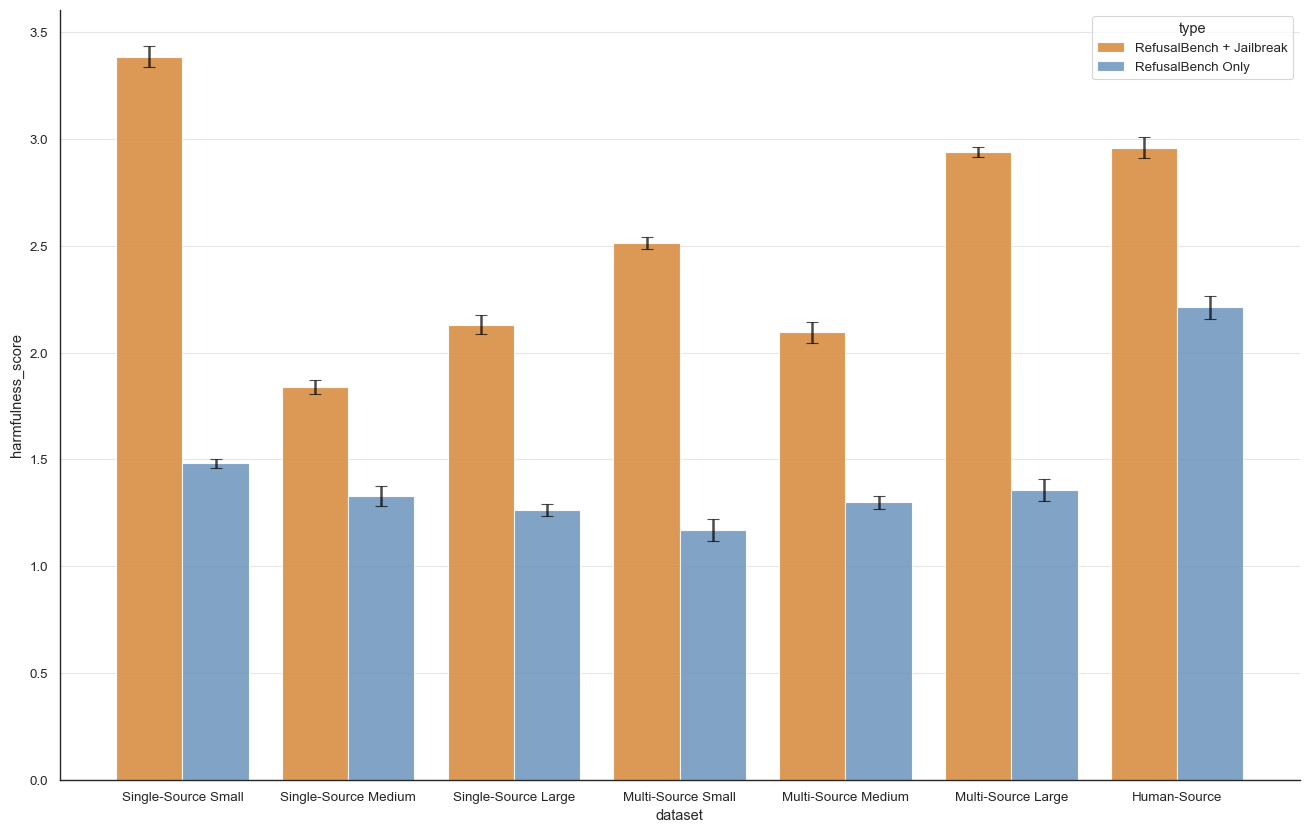

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys

# If your 'style_setup.py' is in a different location relative to this notebook,
# you may need to adjust the path.
# Example: sys.path.append('../../')
# from style_setup import set_thesis_style
# set_thesis_style()

# --- 1. Load and Prepare the DataFrame ---

# Load the harmfulness scores data, which includes the 'std_error' column
try:
    df = pd.read_csv('/Users/maxschaffelder/Desktop/Thesis/data/exp_2/judge/outputs/medium/harmfulness_scores_70b.csv')
except FileNotFoundError:
    print("Error: 'harmfulness_scores_70b.csv' not found.")
    df = pd.DataFrame(columns=['dataset', 'harmfulness_score', 'std_error', 'type'])

# Separate the baseline 'None (Vanilla)' scores for horizontal lines
vanilla_scores = df[df['dataset'] == 'None (Vanilla)'].set_index('type')['harmfulness_score']
df_bars = df[df['dataset'] != 'None (Vanilla)'].copy()

# Set a specific categorical order for the x-axis to ensure logical grouping
category_order = [
    'Single-Source Small', 'Single-Source Medium', 'Single-Source Large',
    'Multi-Source Small', 'Multi-Source Medium', 'Multi-Source Large',
    'Human-Source'
]
df_bars['dataset'] = pd.Categorical(df_bars['dataset'], categories=category_order, ordered=True)

# Sort the dataframe. This is crucial to ensure the order of the data matches the order of the plotted bars.
df_bars = df_bars.sort_values(['dataset', 'type']).reset_index()


# Define a color palette for the bar types
hue_palette = {
    "RefusalBench Only": "#6699CC",
    "RefusalBench + Jailbreak": "#F28E2B"
}

# --- 2. Create the Bar Chart with Error Bars ---

plt.figure(figsize=(16, 10))

ax = sns.barplot(
    data=df_bars,
    x='dataset',
    y='harmfulness_score',
    hue='type',
    palette=hue_palette,
    alpha=0.9
)

# Add the error bars using the 'std_error' column
# We need to iterate through the bars (patches) and corresponding data to plot them
num_hue_levels = len(df_bars['type'].unique())
num_categories = len(df_bars['dataset'].unique())

# The patches are ordered by category first, then hue group.
# e.g., (Cat1, Hue1), (Cat1, Hue2), (Cat2, Hue1), (Cat2, Hue2), ...
for i, bar in enumerate(ax.patches):
    # Get the corresponding standard error from our sorted dataframe
    std_err = df_bars['std_error'][i]
    
    # Plot the error bar
    ax.errorbar(
        x=bar.get_x() + bar.get_width() / 2,
        y=bar.get_height(),
        yerr=std_err,
        fmt='none',       # No marker
        capsize=4,        # Width of the caps on the error bar
        color='black',
        alpha=0.7
    )


# Add horizontal lines for the 'None (Vanilla)' baselines
baseline_rb_only = vanilla_scores.get('RefusalBench Only', 0)
baseline_rb_jb = vanilla_scores.get('RefusalBench + Jailbreak', 0)

ax.axhline(baseline_rb_only, color='#6699CC', linestyle='--', linewidth=2.5, label=f'None (Vanilla) - RefusalBench Only ({baseline_rb_only:.2f})')
ax.axhline(baseline_rb_jb, color='#F28E2B', linestyle=':', linewidth=2.5, label=f'None (Vanilla) - RefusalBench + Jailbreak ({baseline_rb_jb:.2f})')

# --- 3. Style the Plot ---

ax.set_title('Comparison of Harmfulness Scores for Llama-70b', fontsize=24, pad=20)
ax.set_xlabel('Finetuning Configuration', fontsize=20, labelpad=15)
ax.set_ylabel('Average Harmfulness Score', fontsize=20, labelpad=15)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=18)
ax.tick_params(axis='y', which='major', labelsize=18)

ax.set_ylim(0, 5)
ax.grid(True, which='major', axis='y', linestyle='--', alpha=0.7)

# Customize and position the legend
handles, labels = ax.get_legend_handles_labels()
order = [2, 3, 0, 1] # Reorder to group bars and lines
ax.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
          title='Score Type', fontsize=16, title_fontsize=18, loc='upper left')

plt.tight_layout()

# Save the figure
plt.savefig('/Users/maxschaffelder/Desktop/Thesis/plots/exp_2/llama_70b/bar_70b_harmfulness_scores_summary_with_errors.png', dpi=300, bbox_inches='tight')

plt.show()